# Анализ результатов AB-тестирования

Заказчик — интернет-магазин BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Задача — провести оценку результатов A/B-теста. В нашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Требуется оценить корректность проведения теста и проанализировать его результаты.

## 1. Цели исследования



**Цели**: Оценить корректность проведения A/B-теста и проанализировать его результаты.

**Задачи**:
1. Загрузка данных и знакомство с ними.
2. Проверка корректности проведения A/B-теста: соответствие требованиям технического задания, равномерность распределения пользователей по группам теста, отсутствие пересечений.
3. Проверка результатов A/B-теста.
4. Выводы по результатам A/B-теста.

## 2. Загрузка данных, оценка их целостности


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [6]:
participants = pd.read_csv('ab_test_participants.csv')
events = pd.read_csv('ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)

In [7]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [8]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [9]:
participants.duplicated().sum()

0

Датасет `ab_test_participants` содержит 4 столбца и 14525 строк. Пропуски и полные дубликаты в данных отсутствуют.

In [10]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [11]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [12]:
events.duplicated().sum()

36318

Датасет `ab_test_events`содержит 4 столбца и 787286 строк. Пропуски содержатся только в столбце `details`. Датасет содержит 36318 полных дубликата. В контексте нашей задачи у нас нет возможности уточнить у сотрудника, занимавшегося сбором данных, о причине возникновения дублей, они могут отражать реальное поведение пользователей: повторные клики, перезагрузки, возвраты, проблемы с интерфейсом. Поэтому дубли оставлены без изменений.

## 3. Оценка корректности проведения теста

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [13]:
t_1 = participants[participants['ab_test']=='interface_eu_test']['user_id'].unique()
t_2 = participants[participants['ab_test']=='recommender_system_test']['user_id'].unique()
bad_users = list(set(t_1)&set(t_2))
participants = participants[~participants['user_id'].isin(bad_users)]
participants.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12751 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  12751 non-null  object
 1   group    12751 non-null  object
 2   ab_test  12751 non-null  object
 3   device   12751 non-null  object
dtypes: object(4)
memory usage: 498.1+ KB


In [22]:
df = participants[participants['ab_test']=='interface_eu_test']
group_a = df[df['group']=='A']
group_b = df[df['group']=='B']

In [23]:
count_a = group_a['user_id'].nunique()
count_b = group_b['user_id'].nunique()
print(f'Количество уникальных пользователей группы A = {count_a}, группы B = {count_b}')
perc_a = round(count_a / df['user_id'].nunique(), 3)
perc_b = round(count_b / df['user_id'].nunique(), 3)
print(f'Процентное соотношение групп: A = {perc_a}, группы B = {perc_b}')

Количество уникальных пользователей группы A = 4952, группы B = 5011
Процентное соотношение групп: A = 0.497, группы B = 0.503


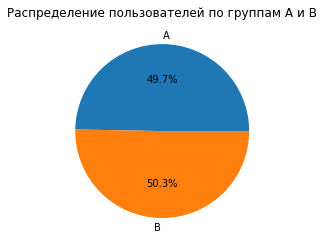

In [24]:
df_group = df.groupby('group')['user_id'].nunique()
plt.figure(figsize=(4, 4))
df_group.plot(kind='pie', autopct='%1.1f%%', legend=False)
plt.ylabel('')
plt.title('Распределение пользователей по группам A и B')
plt.show()

In [25]:
users_a = group_a['user_id']
users_b = group_b['user_id']
intersection = list(set(users_a)&set(users_b))
print(intersection)

[]


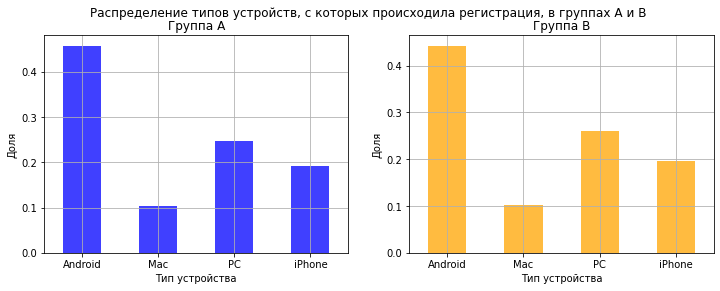

In [26]:
device_a = group_a.groupby('device')['user_id'].nunique().sort_index() / count_a
device_b = group_b.groupby('device')['user_id'].nunique().sort_index() / count_b

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

device_a.plot(kind='bar', rot=0, alpha=0.75, color='blue', ax=axes[0])
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля')
axes[0].set_title('Группа A')
axes[0].grid()

device_b.plot(kind='bar', rot=0, alpha=0.75, color='orange', ax=axes[1])
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Доля')
axes[1].set_title('Группа B')
axes[1].grid()

fig.suptitle('Распределение типов устройств, с которых происходила регистрация, в группах A и B')
plt.show()

- Процентное соотношение пользователей в группах A и B составляет 49.7% к 50.3%. Расхождение количества пользователей между группами минимальное, им можно пренебречь.
- Выборки являются независимыми: пользователи, попавшие в обе группы, отсутствуют.
- Распределение количества уникальных пользователей по типам устройств, с которых происходила регистрация, в тестовой и контрольной группах практически совпадает.

Таким образом, пользователи распределены между группами равномерно, аудитория в них сопоставима. Следовательно, A/B-тест проходит корректно.

---

3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [27]:
df_exp = events.merge(df, on='user_id', how='inner')
df_exp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 73815 entries, 0 to 73814
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     73815 non-null  object        
 1   event_dt    73815 non-null  datetime64[ns]
 2   event_name  73815 non-null  object        
 3   details     19450 non-null  object        
 4   group       73815 non-null  object        
 5   ab_test     73815 non-null  object        
 6   device      73815 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.5+ MB


- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [28]:
df_exp['event_name'].unique()

array(['registration', 'login', 'product_page', 'product_cart',
       'purchase'], dtype=object)

In [29]:
reg_dates = df_exp[df_exp['event_name']=='registration']
reg_dates = reg_dates.rename(columns={'event_dt': 'reg_dt'})
df_exp = df_exp.merge(reg_dates[['user_id', 'reg_dt']], on='user_id', how='left')
df_exp['day_since_registration'] = df_exp['event_dt'] - df_exp['reg_dt']
df_exp = df_exp[df_exp['day_since_registration']<=pd.Timedelta(days=7)].reset_index()
df_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63805 entries, 0 to 63804
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   index                   63805 non-null  int64          
 1   user_id                 63805 non-null  object         
 2   event_dt                63805 non-null  datetime64[ns] 
 3   event_name              63805 non-null  object         
 4   details                 16125 non-null  object         
 5   group                   63805 non-null  object         
 6   ab_test                 63805 non-null  object         
 7   device                  63805 non-null  object         
 8   reg_dt                  63805 non-null  datetime64[ns] 
 9   day_since_registration  63805 non-null  timedelta64[ns]
dtypes: datetime64[ns](2), int64(1), object(6), timedelta64[ns](1)
memory usage: 4.9+ MB


- оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

 базовый показатель конверсии — 30%,  
 мощность теста — 80%,  
 достоверность теста — 95%.

In [30]:
alpha = 0.05  # Уровень значимости
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


In [31]:
# Повторно выделим группы после фильтрации событий в течение 7 дней после регистрации (количество пользователей могло уменьшиться)
group_a = df_exp[df_exp['group']=='A']
group_b = df_exp[df_exp['group']=='B']

Размеры выборок достаточные для получения статистически значимых результатов A/B-теста.

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [32]:
count_a_purchase = group_a[group_a['event_name']=='purchase']['user_id'].nunique()
count_b_purchase = group_b[group_b['event_name']=='purchase']['user_id'].nunique()
print(f'Количество пользователей, сделавших покупку, в группе A = {count_a_purchase}, в группе B = {count_b_purchase}')
count_a = group_a['user_id'].nunique()
count_b = group_b['user_id'].nunique()
print(f'Количество уникальных пользователей группы A = {count_a}, группы B = {count_b}')
conversion_a = count_a_purchase / count_a
conversion_b = count_b_purchase / count_b
print(f'Конверсия зарегистрированных пользователей в покупателей в группе A = {round(100 * conversion_a, 2)}%, в группе B = {round(100 * conversion_b, 2)}%')

Количество пользователей, сделавших покупку, в группе A = 1377, в группе B = 1480
Количество уникальных пользователей группы A = 4952, группы B = 5011
Конверсия зарегистрированных пользователей в покупателей в группе A = 27.81%, в группе B = 29.54%


3\.3 Предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной:

Конверсия зарегистрированных пользователей в покупателей в тестовой группе повысилась на 1.73% по сравнению с контрольной, что ниже запланированного роста (3%).

## 4. Оценка результатов A/B-тестирования:

Проверим изменение конверсии подходящим статистическим тестом.

Целевая метрика - конверсия зарегистрированных пользователей в покупателей. Обозначим {$p_a$, $p_b$} как конверсии зарегистрированных пользователей в покупателей для старой и новой версии сайта. Сформулируем гипотезы для А/B-теста:
- Нулевая гипотеза $H_0$: конверсия зарегистрированных пользователей в покупателей не различается для старой и новой версии - $p_a$ = $p_b$.
- Альтернативная гипотеза $H_1$: конверсия зарегистрированных пользователей в покупателей выше для новой версии - $p_a$ < $p_b$.

In [33]:
# Проводим Z-тест пропорций
if (conversion_a*count_a > 10)and((1-conversion_a)*count_a > 10)and(conversion_b*count_b > 10)and((1-conversion_b)*count_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется')
    
stat_ztest, p_value_ztest = proportions_ztest(
    [count_a_purchase, count_b_purchase],
    [count_a, count_b],
    alternative='smaller' # так как H_1: p_a < p_b
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение.')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения.')

Предпосылка о достаточном количестве данных выполняется
pvalue=0.028262547212292124 < 0.05
Нулевая гипотеза не находит подтверждения.


Выводы по проведённой оценке результатов A/B-тестирования:
- Целевой метрикой эксперимента являлась конверсия зарегистрированных пользователей в покупателей. Количество пользователей в контрольной группе составило 4952, в тестовой - 5011.
- Внедрение новой версии сайта привело к росту ключевой метрики в тестовой группе на 1.73 процентных пункта, что ниже запланированного MDE в 3 процентных пункта.
- При оценке статистической значимости данного эффекта значение p-value = 0.03 получилось ниже заданного уровня значимости 0.05, поэтому нет оснований принимать нулевую гипотезу о равенстве конверсий зарегистрированных пользователей в покупателей. Это означает, что существует статистически значимое различие между конверсиями зарегистрированных пользователей в покупателей в группах A и B.
- Новая версия сайта действительно привела к росту конверсии зарегистрированных пользователей в покупателей, однако его величина меньше запланированного.